## Datasets and research question

I am looking at two sets of estimated ages: van den Berg (55 rows) and Krause (61 rows). I want to find out whether any clusters have unusual ages compared with other clusters of similar metallicity.

### Fields I need 

`Age`: estimated age of a cluster, in billions of years
`FeH`: metallicity. It compares the amount of iron with hydrogen; higher value (for example -0.8 instead of -2.0) means more iron relative to hydrogen. It is a relative field, it has no unit.
- `Age_err`: the age error listed by van den Berg, in billions of years. Krause does not have this field.
- '#NGC' and 'Name' in van den Berg and 'Object' in Krause: names or numbers used to identify clusters and compare it across files.

I checked the row counts, column names and example rows. Neither file has missing values in 'Age' or 'FeH'. Some van den Berg `Name` entries are `XXXX`, so I cannot rely on that column alone when matching clusters.

### stuff I noticed on a first look 

The ages spread more widely in Krause than in van den Berg. Pal 12 is young in both files: 9.0 billion in van den Berg and 8.6 in Krause. Some ages differ a lot between files: NGC 1851 is 11.0 in van den Berg but 7.64 in Krause, while NGC 7099 is 13.0 versus 14.6. Terzan 7 is young in Krause (7.4) but I cannot find it in van den Berg.

These are points to check later, not final outliers. I need to compare ages at similar metallicities and also look carefully at the clusters where the two files disagree.

## Choosing which measurements to use

Krause has 61 rows, and every row is labelled 'GC' (globular cluster). Van den Berg has 55 rows. Neither file has missing 'Age' or 'FeH' values, so I can use all 61 and 55 rows for the first age-metallicity plots.

I will show van den Berg's values first cuz it also gives me 'Age_err', then show Krause's values separately for comparison. This does not mean van den Berg is automatically correct.

If the two files give different ages for the same cluster, I will keep both values and their source names visible. I will not average them. I will check the larger disagreements later before deciding how much confidence to put on outliers.

In [33]:
import re
import pandas as pd 

vanderberg = pd.read_csv("vandenBerg_table2.csv")
krause = pd.read_csv("Krause21.csv")
harris = pd.read_csv("HarrisPartI.csv")


def vdb_harris_id(row):
    # most van der berg has an NGC number such as 104
    ngc = str(row['#NGC']).strip()

    # Harris writes the same clusters as "NGC 104"
    if ngc.isdigit():
        return f"NGC {ngc}"

    # if the NGC says XXXX the we try the clusters other names, we only include names 
    # we checked
    checked_names = {
        "Pal12": "Pal 12",
        "Ter8" : "Terzan 8",
        "Arp21" : "Arp 2"
    }

    # if no name, we come back
    return checked_names.get(str(row["Name"]).strip())

def krause_harris_id(object_name):
    # Krause writes names like "NGC104" without space
    name = str(object_name).strip()
    ngc = re.fullmatch(r"NGC\s*(\d+)", name)

    # Turn NGC104 inot Harris "NGC 104"
    if ngc:
        return f"NGC {ngc.group(1)}"

    # These names are written differently in Krause and Harris so we gotta fix them
    checked_names = {
        "Ruprecht106": "Rup 106",
        "Terzan7": "Terzan 7",
        "Palomar12": "Pal 12",

    }

    # leave the rest unmatched

    return checked_names.get(name)

# Add a new matching ID to each age table
# original stuff is unchanged
vanderberg["harris_id"] = vanderberg.apply(vdb_harris_id, axis=1)
krause["harris_id"] = krause["Object"].map(krause_harris_id)

harris_ids = set(harris["ID"])

for source, data, original_id in [
    ("van den Berg", vanderberg, "Name"),
    ("Krause", krause, "Object"),
]:

    matched = data["harris_id"].isin(harris_ids)

    # seperate the done stuff from the useless one
    print(source, "matched:", matched.sum(), "out of", len(data))
    print("Unmatched rows:")
    print(data.loc[~matched, [original_id, "harris_id", "Age", "FeH"]])

    print("Repeated matching IDs:", data["harris_id"].dropna().duplicated().sum())

van den Berg matched: 55 out of 55
Unmatched rows:
Empty DataFrame
Columns: [Name, harris_id, Age, FeH]
Index: []
Repeated matching IDs: 0
Krause matched: 61 out of 61
Unmatched rows:
Empty DataFrame
Columns: [Object, harris_id, Age, FeH]
Index: []
Repeated matching IDs: 0


In [34]:
vanderberg_table = vanderberg[["harris_id", "Age", "FeH", "Age_err"]].copy()

vanderberg_table["source"] = "van den Berg"

krause_table = krause[
    ["harris_id", "Age", "FeH"]
].copy()

# krause does not reallt have age_err blank means unknown not zero
krause_table["Age_err"] = pd.NA
krause_table["source"] = "Krause"

# Now we put both rows in tablebut we DO NOTTT avergae them
age_metal_table = pd.concat(
    [vanderberg_table, krause_table],
    ignore_index=True
)

# just put the ID column into a name and arrange the columns
age_metal_table = age_metal_table.rename(columns={"harris_id": "ID"})[
    ["ID", "source", "Age", "FeH", "Age_err"]
]

print("TOtal rows: ", len(age_metal_table))
display(age_metal_table.head(10))

TOtal rows:  116


,ID,source,Age,FeH,Age_err
0,NGC 104,van den Berg,11.75,-0.76,0.25
1,NGC 288,van den Berg,11.50,-1.32,0.38
2,NGC 362,van den Berg,10.75,-1.30,0.25
3,NGC 1261,van den Berg,10.75,-1.27,0.25
4,NGC 1851,van den Berg,11.00,-1.18,0.25
5,NGC 2808,van den Berg,11.00,-1.18,0.38
6,NGC 3201,van den Berg,11.50,-1.51,0.38
7,NGC 4147,van den Berg,12.25,-1.78,0.25
8,NGC 4590,van den Berg,12.00,-2.27,0.25
9,NGC 4833,van den Berg,12.50,-1.89,0.5


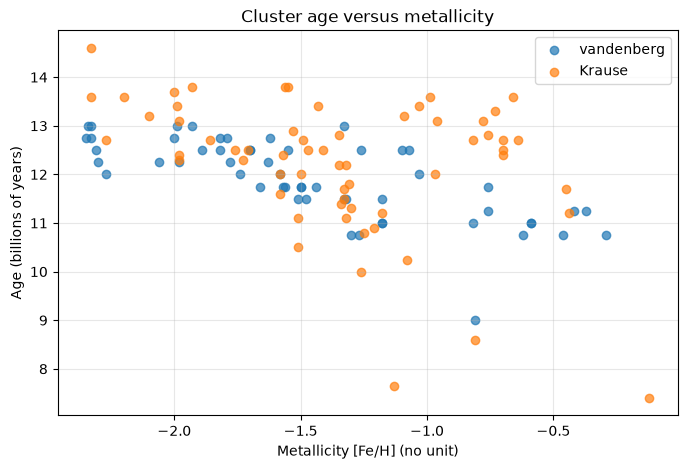

van den Berg points: 55
Krause points: 61
Excluded rows: 0


In [35]:
import matplotlib.pyplot as plt

# simple plot, I dont think this needs an explanation

plot_data = age_metal_table.dropna(subset=["FeH", "Age"])

vanderberg_plot = plot_data[plot_data["source"] == "van den Berg"]
krause_plot = plot_data[plot_data["source"] == "Krause"]

plt.figure(figsize=(8,5))

plt.scatter(vanderberg_plot["FeH"], vanderberg_plot["Age"], label="vandenberg", alpha=0.7)

plt.scatter(krause_plot["FeH"], krause_plot["Age"],
            label="Krause", alpha=0.7)

plt.xlabel("Metallicity [Fe/H] (no unit)")
plt.ylabel("Age (billions of years)")
plt.title("Cluster age versus metallicity")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("van den Berg points:", len(vanderberg_plot))
print("Krause points:", len(krause_plot))
print("Excluded rows:", len(age_metal_table) - len(plot_data))

#### Look at Age and Metallicity graph

We plotted the graph of age against metallicity for both the sources, using different colours so I can see which measurement came from which file. This graph includes 55 van den Berg and 61 Krause measurements. No rows were excluded for missing age or metallicity.

Most of these have ages between 11 and 13 billion years. Krause has a wider spread of ages than van den Berg, and some points look much younger or older than most others. The same cluster can also appear twice cuz two sources may have different age so 116 points does not mean 116 clusters.

This is first look, not a conclusive outlier test. I still need to compare clusters with others of similar metallicity and see if they agree. 

In [36]:
# these are the rules we set that we will use to construct the flagged list
metallicity_window = 0.25 # how close the other clusters FeH needs to be
minimum_neighbours = 4 # we need at least four other clusters for a comparison
age_cutoff = 2.0 # we kinda only flag if it differs by at least 2 billion years

checks = []

# now we work through each source seperately
# split the table so like Krause and others are only compared Krause. 
for source, sources_rows in age_metal_table.groupby("source"):
    # now we look at one clusters at a time within that source
    for _, cluster in sources_rows.iterrows():

        # now we keep rows that ae not this cluster and have nearby FeH values
        nearby = sources_rows[
            (sources_rows["ID"] != cluster["ID"]) &
            ((sources_rows["FeH"] - cluster["FeH"]).abs() <= metallicity_window)
        ]

        # now we start these as missing; they stay missing if there aren't enough neighbours.
        middle_age = float("nan")
        age_difference = float("nan")

        # do not judge a cluster if it only has less than the min neighbours
        if len(nearby) < minimum_neighbours:
            result = "not enough to compare"
        else:
            # now we find the middle of the nearby clusters
            middle_age = nearby["Age"].median()
            # positive = this cluster is older; negative = it is younger
            age_difference = cluster["Age"] - middle_age

            # now we check whether it differs by at least 2 billion years
            if age_difference >= age_cutoff:
                result = "flagged older"
            elif age_difference <= -age_cutoff:
                result = "flagged younger"
            else:
                result = "not flagged"

        # now we add this clusters details and result to our list
        checks.append({
            "ID": cluster["ID"],
            "source": source,
            "Age": cluster["Age"],
            "FeH": cluster["FeH"],
            "Age_err": cluster["Age_err"],
            "nearby_count": len(nearby),
            "middle_age": middle_age,
            "age_difference": age_difference,
            "result": result
        })

# now we turn this into a pandas table
age_checks = pd.DataFrame(checks)
# now we count how many rows got each result in each source.
print(age_checks.groupby(["source", "result"]).size())

# show the shortlist. the full age_checks table still keeps everyone else.
flagged_age = age_checks[
    age_checks["result"].isin(["flagged older", "flagged younger"])
]

# display it, duh
display(flagged_age)

source        result               
Krause        flagged older             1
              flagged younger           2
              not enough to compare     2
              not flagged              56
van den Berg  flagged younger           1
              not enough to compare     1
              not flagged              53
dtype: int64


,ID,source,Age,FeH,Age_err,nearby_count,middle_age,age_difference,result
4,NGC 1851,Krause,7.64,-1.13,<NA>,19,11.7,-4.06,flagged younger
25,NGC 6171,Krause,13.40,-1.03,<NA>,13,11.2,2.20,flagged older
60,Pal 12,Krause,8.60,-0.81,<NA>,13,12.8,-4.20,flagged younger
114,Pal 12,van den Berg,9.00,-0.81,0.38,7,11.0,-2.00,flagged younger


## Looking for unusual ages

I compare each cluster with other clustes from the same dataset that are within 0.25 of its 'FeH' value. This is cuz we wanna keep the comparison local but also want other clusters to compare our cluster with. I leave the cluster itself out and require at least four others.

Then, I use the middle age of nearby clusters cuz a very old or young value will not really pull it as much as average. I flag a cluster when its age is at least 2 billion years older or younger than the middle age of the nearby clusters. These numbers are choices for making a first shortlist, not known boundaries between different kinds of clusters. If there are fewer than four nearby clusters, I say there is not enough to compare.

## First shortlist 

The rule flagged only four measurements; one as older and three as younger. Three other measurements did not have enough nearby clusters for this comparison. A flag only means that an age stands out under this rule. I lowk still need to check the original values, the age uncertainties where available, and like whether changing the rules changes the shortlist. It does NOT tell me where the cluster is formed.

In [37]:
# mostly the previous code y'know
def run_age_rule(window, cutoff):
    results = []

    # now we work through each source seperately
    # split the table so like Krause and others are only compared Krause. 
    for source, sources_rows in age_metal_table.groupby("source"):
        # now we look at one clusters at a time within that source
        for _, cluster in sources_rows.iterrows():

            # now we keep rows that ae not this cluster and have nearby FeH values
            nearby = sources_rows[
                (sources_rows["ID"] != cluster["ID"]) &
                ((sources_rows["FeH"] - cluster["FeH"]).abs() <= window)
            ]

            # now we start these as missing; they stay missing if there aren't enough neighbours.
            middle_age = float("nan")
            age_difference = float("nan")

            # do not judge a cluster if it only has less than the min neighbours
            if len(nearby) < minimum_neighbours:
                result = "not enough to compare"
            else:
                # now we find the middle of the nearby clusters
                middle_age = nearby["Age"].median()
                # positive = this cluster is older; negative = it is younger
                age_difference = cluster["Age"] - middle_age

                # now we check whether it differs by at least 2 billion years
                if age_difference >= cutoff:
                    result = "flagged older"
                elif age_difference <= -cutoff:
                    result = "flagged younger"
                else:
                    result = "not flagged"

            # now we add this clusters details and result to our list
            results.append({
                "ID": cluster["ID"],
                "source": source,
                "Age": cluster["Age"],
                "FeH": cluster["FeH"],
                "Age_err": cluster["Age_err"],
                "nearby_count": len(nearby),
                "middle_age": middle_age,
                "age_difference": age_difference,
                "result": result
            })

    return pd.DataFrame(results)

# now we turn this into a pandas table
age_checks = run_age_rule(metallicity_window, age_cutoff)
# now we count how many rows got each result in each source.
print(age_checks.groupby(["source", "result"]).size())

# show the shortlist. the full age_checks table still keeps everyone else.
flagged_age = age_checks[
    age_checks["result"].isin(["flagged older", "flagged younger"])
]

# display it, duh
display(flagged_age)

# different settings we wanna try
setting = [
    ("baseline", 0.25, 2.0),
    ("narrower window", 0.20, 2.0),
    ("wider window", 0.30, 2.0),
    ("lower age cutoff", 0.25, 1.5),
    ("higher age cutoff", 0.25, 2.5),
]

runs = []

for label, window, cutoff in setting:
    this_run = run_age_rule(window=window, cutoff=cutoff)
    this_run["setting"] = label
    runs.append(this_run)

all_runs = pd.concat(runs, ignore_index=True)

# count flagged, unflagged, and unassessable rows in every settig
print(all_runs.groupby(["setting", "result"]).size())

# put each setting in a column for same source and ID
comparison = all_runs.pivot(
    index=["source", "ID"],
    columns="setting",
    values="result"
)

setting_labels = []

for label, windows, cutoff in setting:
    setting_labels.append(label)

comparison = comparison[setting_labels]

#  now show any measurement flagged under at least one setting

flagged_somwewhere = []

for _, row in comparison.iterrows():
    found_flag = False

    for result in row:
        if result.startswith("flagged"):
            found_flag = True
            break

    flagged_somwewhere.append(found_flag)

flagged_somwewhere = pd.Series(
    flagged_somwewhere,
    index=comparison.index
)

display(comparison[flagged_somwewhere])

source        result               
Krause        flagged older             1
              flagged younger           2
              not enough to compare     2
              not flagged              56
van den Berg  flagged younger           1
              not enough to compare     1
              not flagged              53
dtype: int64


,ID,source,Age,FeH,Age_err,nearby_count,middle_age,age_difference,result
4,NGC 1851,Krause,7.64,-1.13,<NA>,19,11.7,-4.06,flagged younger
25,NGC 6171,Krause,13.40,-1.03,<NA>,13,11.2,2.20,flagged older
60,Pal 12,Krause,8.60,-0.81,<NA>,13,12.8,-4.20,flagged younger
114,Pal 12,van den Berg,9.00,-0.81,0.38,7,11.0,-2.00,flagged younger


setting            result               
baseline           flagged older              1
                   flagged younger            3
                   not enough to compare      3
                   not flagged              109
higher age cutoff  flagged younger            2
                   not enough to compare      3
                   not flagged              111
lower age cutoff   flagged older              5
                   flagged younger            5
                   not enough to compare      3
                   not flagged              103
narrower window    flagged older              1
                   flagged younger            3
                   not enough to compare      7
                   not flagged              105
wider window       flagged younger            4
                   not enough to compare      1
                   not flagged              111
dtype: int64


setting                       baseline  narrower window     wider window  \
source       ID                                                            
Krause       NGC 1851  flagged younger  flagged younger  flagged younger   
             NGC 362       not flagged      not flagged  flagged younger   
             NGC 6144      not flagged      not flagged      not flagged   
             NGC 6171    flagged older      not flagged      not flagged   
             NGC 6218      not flagged      not flagged      not flagged   
             NGC 6535      not flagged      not flagged      not flagged   
             NGC 6717      not flagged    flagged older      not flagged   
             NGC 6752      not flagged      not flagged      not flagged   
             Pal 12    flagged younger  flagged younger  flagged younger   
van den Berg Pal 12    flagged younger  flagged younger  flagged younger   

setting               lower age cutoff higher age cutoff  
source       ID                                           
Krause       NGC 1851  flagged younger   flagged younger  
             NGC 362   flagged younger       not flagged  
             NGC 6144    flagged older       not flagged  
             NGC 6171    flagged older       not flagged  
             NGC 6218    flagged older       not flagged  
             NGC 6535  flagged younger       not flagged  
             NGC 6717    flagged older       not flagged  
             NGC 6752    flagged older       not flagged  
             Pal 12    flagged younger   flagged younger  
van den Berg Pal 12    flagged younger       not flagged

In [ ]:
# now these are the three different clusters that keep getting flagged by the main rule
ids_to_check = ["NGC 1851", "NGC 6171", "Pal 12"]

# shows both of the sources together grouped by cluster ID
source_check = age_metal_table[
    age_metal_table["ID"].isin(ids_to_check)
].sort_values(["ID", "source"])

display(source_check)

# now we show original van den berg IDs and measurements
display(vanderberg.loc[
    vanderberg["harris_id"].isin(ids_to_check),
    ["#NGC", "Name", "harris_id", "Age", "FeH", "Age_err"]
])

# same thing with krause
display(krause.loc[
    krause["harris_id"].isin(ids_to_check),
    ["Object", "AltName", "harris_id", "Age", "FeH"]
])

,ID,source,Age,FeH,Age_err
59,NGC 1851,Krause,7.64,-1.13,<NA>
4,NGC 1851,van den Berg,11.00,-1.18,0.25
80,NGC 6171,Krause,13.40,-1.03,<NA>
21,NGC 6171,van den Berg,12.00,-1.03,0.75
115,Pal 12,Krause,8.60,-0.81,<NA>
53,Pal 12,van den Berg,9.00,-0.81,0.38


,#NGC,Name,harris_id,Age,FeH,Age_err
4,1851,XXXX,NGC 1851,11.0,-1.18,0.25
21,6171,M107,NGC 6171,12.0,-1.03,0.75
53,XXXX,Pal12,Pal 12,9.0,-0.81,0.38


,Object,AltName,harris_id,Age,FeH
4,NGC1851,Dunlop508,NGC 1851,7.64,-1.13
25,NGC6171,M107,NGC 6171,13.40,-1.03
60,Palomar12,NONE,Pal 12,8.60,-0.81


## Checking the age flags

I repeated the age comparison with slightly different metallicity ranges and slightly different age-difference limits. This lets us check whether a cluster stands out most of the time or only with one specific set of settings.

In the Krause data, NGC 1851 and Pal 12 were flagged as, like, younger under all five settings tested. NGC 6171 was flagged as older under only some of the settings, so its result varies a bit more. In the van den Berg data, Pal 12 was flagged as younger under four of the five settings.

I also compared clusters that appeared in both datasets. Both give Pal 12 a similar young age, which makes the result more convincing. They disagree more about the age of NGC 1851, so I will keep it as a candidate to investigate, not remove it from the results. Krause does not provide an age error in this table, so the thing is, we can't exactly know which age estimate is more reliable from these tables alone.

The reason we did this was to check whether the age results are stronger or need more caution. An unusual age does not really establish where a cluster formed. We need to consider that alongside the motion data in the Harris parts.

In [ ]:
# just exporting to a file gng
age_out = age_checks[["ID", "source", "Age", "FeH", "Age_err", "result"]].copy()

age_out.to_csv("age_checked.csv", index=False)
